### 1.Modelo de regressão descontínua - Fuzzy

O conjunto de códigos tem como objetivo seguir algumas orientações do artigo _Regression Discontinuity Designs: A Guide to Practice_, publicado na _Journal of Econometrics_ (v. 142, n. 2, p. 615-635, 2008), dos autores Guido Imbens e Thomas Lemieux. Este artigo aborda o método de regressão descontinua, com foco específico no desenho fuzzy. O artigo pode ser encontrado no [National Bureau of Economic Research - NBER](https://www.nber.org/papers/w13039).

Além disso, os códigos utilizados para a estimação econométrica foram adaptados para a linguagem Python a partir da página [Program Evaluation for Public Service](https://evalf20.classes.andrewheiss.com/example/rdd-fuzzy/) do professor Andrew Heiss, que originalmente utilizou o programa RStudio.

### 2. Bibliotecas

In [36]:
# Manipulação dos dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

# Estatística/Econometria
from rddensity import rddensity
from rdrobust import rdrobust, rdplot, rdbwselect
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS

### 3. Criando o conjunto de dados fictício

📌 Cenário: Isenção de Imposto para Pequenas Empresas

- Empresas com faturamento anual abaixo de R$500.000 podem receber isenção fiscal.
- No entanto, nem todas abaixo do limite conseguem (burocracia, critérios adicionais), e algumas acima do limite ainda conseguem a isenção.
- O impacto é medido no crescimento, em porcentagem, da receita após um ano.
- Covariáveis incluem número de funcionários, idade da empresa e setor de atuação.

In [22]:
n = 5000
np.random.seed(0)

faturamento_anual = np.random.uniform(100000, 600000, n)  # Faturamento entre 100k e 600k
num_funcionarios = np.random.randint(1, 50, n)  # Funcionários entre 1 e 50
idade_empresa = np.random.randint(1, 20, n)  # Idade da empresa entre 1 e 20 anos
setor = np.random.choice(['Comércio', 'Serviços', 'Indústria'], n)  # Setor de atuação

# Probabilidade de receber isenção (Fuzzy RD)
prob_isencao = 0.85 * (faturamento_anual < 500000) + 0.15 * (faturamento_anual >= 500000)
tratamento_fuzzy_3 = np.random.binomial(1, prob_isencao, n)

# Resultado: Crescimento da receita após um ano
crescimento_receita = 5 + 0.00002 * faturamento_anual + 2.5 * tratamento_fuzzy_3 + 0.1 * num_funcionarios + np.random.normal(0, 1, n)

# Criar DataFrame Fuzzy RD
df = pd.DataFrame({
    'faturamento_anual': faturamento_anual, 
    'num_funcionarios': num_funcionarios, 
    'idade_empresa': idade_empresa,
    'setor': setor, 
    'tratamento': tratamento_fuzzy_3, 
    'crescimento_receita': crescimento_receita
})

In [23]:
# Primeiras observações
df.head()

,faturamento_anual,num_funcionarios,idade_empresa,setor,tratamento,crescimento_receita
0,374406.751964,44,17,Indústria,1,19.494170
1,457594.683186,10,19,Comércio,1,18.175875
2,401381.688036,36,1,Indústria,1,19.655165
3,372441.591498,15,18,Indústria,1,14.991701
4,311827.399669,33,18,Indústria,1,16.977536


In [24]:
# Variável para facilitar visualização
df['tratamento_texto'] = df['tratamento'].map({0: 'Sem incentivo', 1: 'Com incentivo'})

### 4. Contextualizando o programa fictício

- Critério de Isenção: Empresas com faturamento anual abaixo de R$500.000 são elegíveis para um programa de isenção fiscal.

- Desvios na Elegibilidade: Algumas empresas dentro do critério não recebem o benefício devido a burocracia ou exigências adicionais, enquanto algumas acima do limite conseguem a isenção.

- Métrica de Impacto: O efeito do programa é avaliado pelo crescimento percentual da receita das empresas após um ano.

- Variáveis de Controle: A análise considera fatores como número de funcionários, idade da empresa e setor de atuação para entender melhor os efeitos da isenção.

### 5. Plotando os dados

Assim como no desenho sharp é essencial plotar os dados para verificar qual abordagem devemos seguir. Apesar de já sabermos que o desenho adotado é do tipo fuzzy, abaixo, será feito a plotagem dos dados da variável que foi utilizada como referência de cut-off.

No gráfico abaixo, os pontos azuis representam empresas que receberam o incentivo, enquanto os pontos vermelhos indicam empresas que, em teoria, deveriam estar no grupo de controle. Observa-se que algumas empresas que deveriam ter acesso ao programa não participaram, enquanto outras que não deveriam participaram.

No eixo y, em "Sem incentivo", os pontos azuis representam empresas que poderiam ou deveriam ter participado do programa, mas não o fizeram. Já os pontos vermelhos indicam empresas que não eram elegíveis para o programa e, de fato, não participaram.

Por outro lado, em "Com incentivo", a maioria das empresas que receberam o incentivo estavam no grupo correto. No entanto, há pontos vermelhos nessa categoria, representando empresas que não deveriam ter participado, mas acabaram recebendo o incentivo.

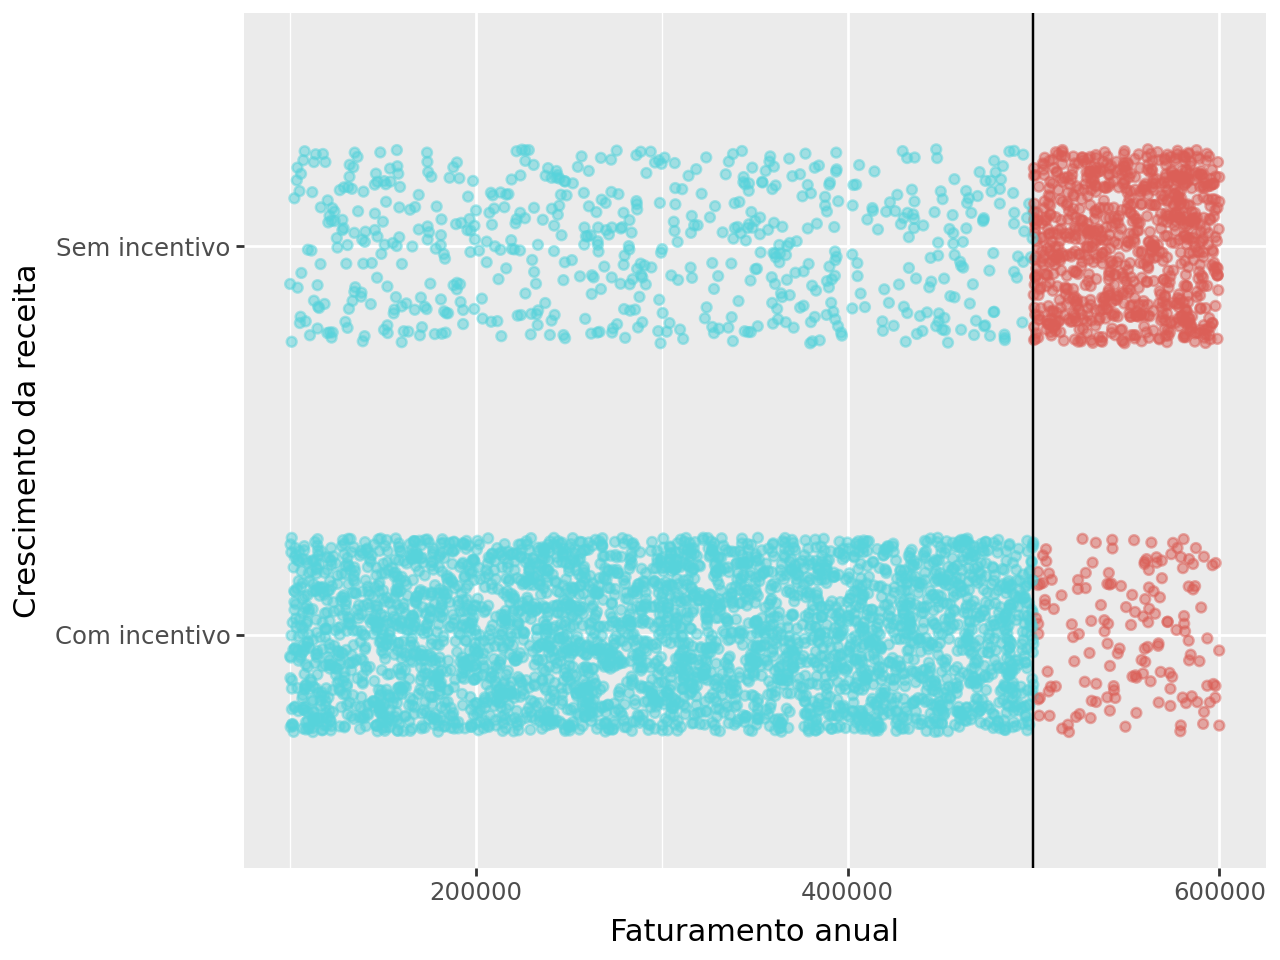

In [25]:
plot = (
    ggplot(df , aes(x='faturamento_anual', y='tratamento_texto', color=df['faturamento_anual'] <= 500000))
    + geom_point(size=1.5, alpha=0.5, position=position_jitter(width=0, height=0.25, random_state=1234))
    + geom_vline(xintercept=500000)
    + labs(x='Faturamento anual', y='Crescimento da receita')
    + guides(color=False)
)

plot

Para confirmar o que mostra o gráfico será criado uma tabela. 150 empresas tiveram um faturamento maior que 500k e mesmo assim participaram do programa, 566 empresas faturaram menos que 500k e não participaram.

In [26]:
# Adicionar uma coluna indicando se o faturamento é menor ou igual a 500k
df['faturamento_anual_<=500k'] = df['faturamento_anual'] <= 500000

# Contar o número de ocorrências para cada combinação de 'tratamento_texto' e 'faturamento_anual_<=500k'
count_df = df.groupby(['tratamento_texto', 'faturamento_anual_<=500k']).size().reset_index(name='count')

# Calcular a soma total de 'count' para cada 'tratamento_texto'
total_count = count_df.groupby('tratamento_texto')['count'].transform('sum')

# Calcular a proporção dividindo 'count' pela soma total
count_df['prop'] = count_df['count'] / total_count

# Exibir o resultado
print(count_df)

  tratamento_texto  faturamento_anual_<=500k  count      prop
0    Com incentivo                     False    150  0.042337
1    Com incentivo                      True   3393  0.957663
2    Sem incentivo                     False    847  0.581332
3    Sem incentivo                      True    610  0.418668


#### 5.1 Verificando se há descontinuidade

Abaixo, é realizada uma regressão paramétrica para verificar se há um gap (ou seja, o tamanho do impacto do programa). No entanto, devido à quantidade de empresas que não seguem ou não obedecem às regras, essa abordagem não nos permitirá identificar o efeito real do programa, ainda que indique a existência de um impacto.

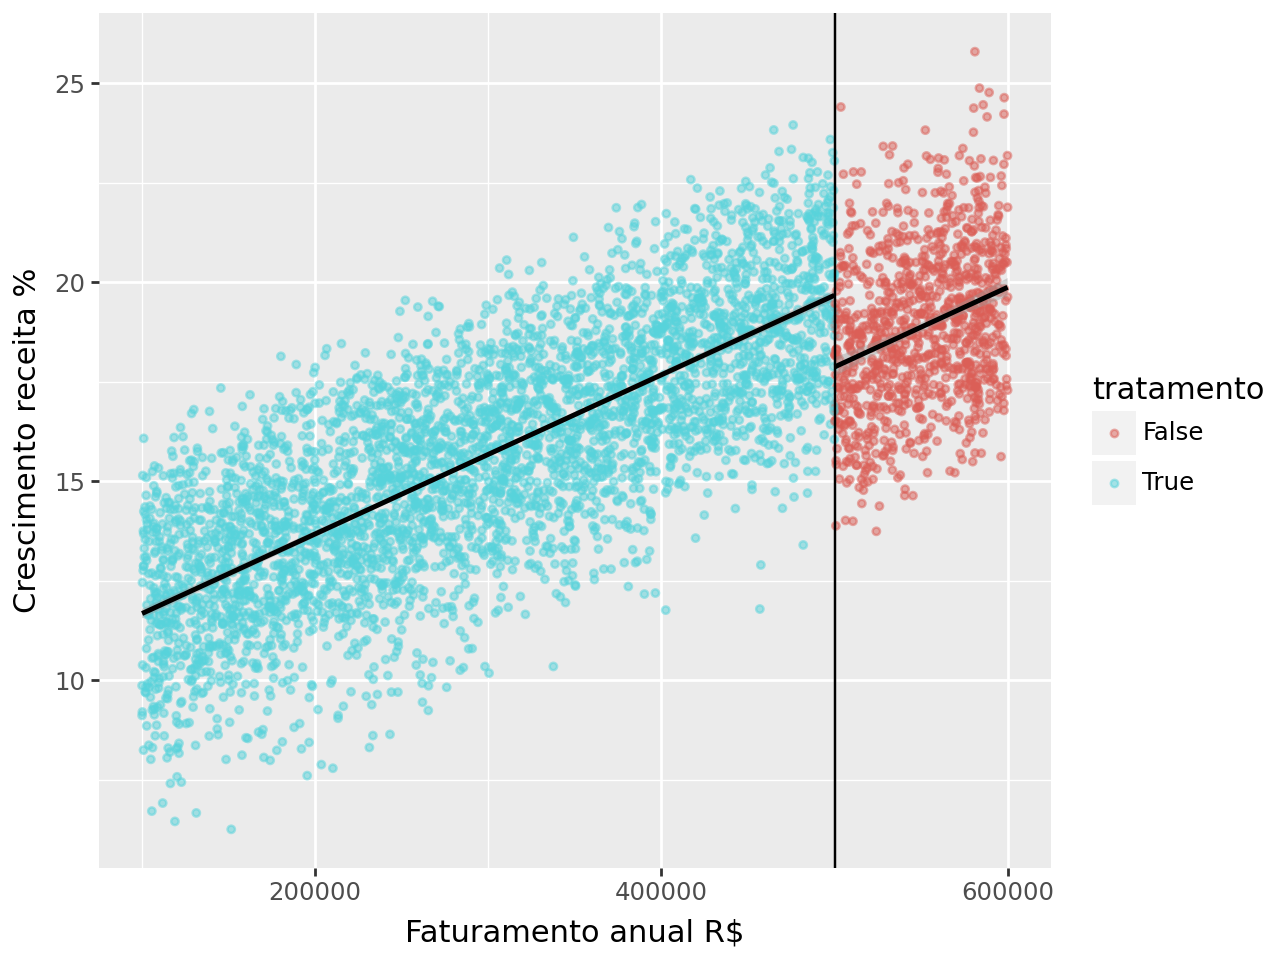

In [27]:
plot = (
    ggplot(df, aes(x='faturamento_anual', y='crescimento_receita', color='faturamento_anual_<=500k'))
    + geom_point(size=1, alpha=0.5)
    + geom_smooth(data=df[df['faturamento_anual'] <= 500000], method='lm', se=True, color='black')
    + geom_smooth(data=df[df['faturamento_anual'] > 500000], method='lm', se=True, color='black')
    + geom_vline(xintercept=500000)
    + labs(x='Faturamento anual R$', y='Crescimento receita %', color='tratamento')
)

plot

Confirmando que há várias empresas tanto do grupo de tratamento quanto do grupo de controle que não estão em seus respectivos grupos. Pela figura abaixo, observa-se que, entre as empresas com faturamento inferior a 500K, a probabilidade de participar do programa é de 80%, enquanto entre aquelas com faturamento superior a 500K, a probabilidade é de apenas 20%. Esse padrão não deveria ocorrer.

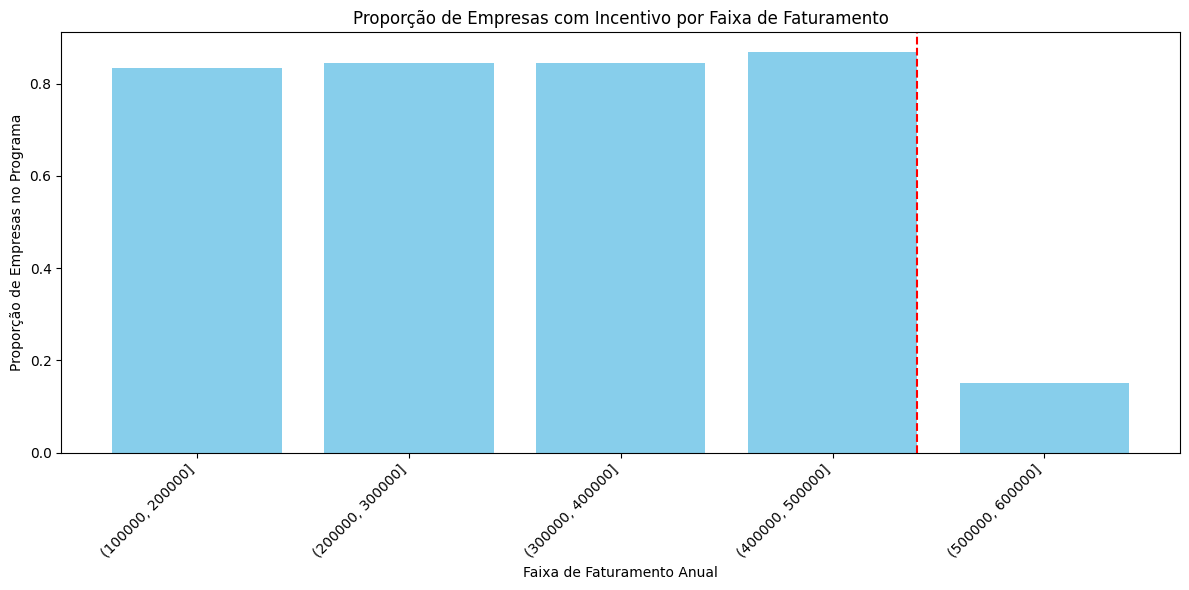

In [35]:
# Criando os bins para 'faturamento_anual'
bins = np.arange(0, 1100000, 100000)  # Intervalos de 100k até 1.1M
labels = [f'({i}, {i+100000}]' for i in bins[:-1]]
df['faturamento_binned'] = pd.cut(df['faturamento_anual'], bins=bins, labels=labels, right=True)

# Agrupando por faixa de faturamento e status do tratamento
grouped = df.groupby(['faturamento_binned', 'tratamento']).size().unstack(fill_value=0)

# Renomeando colunas para melhor legibilidade
grouped.columns = ['Sem incentivo', 'Com incentivo']

# Calculando a proporção de empresas com incentivo em cada faixa de faturamento
grouped['prob_tratamento'] = grouped['Com incentivo'] / (grouped['Com incentivo'] + grouped['Sem incentivo'])

# Criando o gráfico
plt.figure(figsize=(12, 6))
plt.bar(grouped.index, grouped['prob_tratamento'], color='skyblue')
plt.axvline(x=4.4, color='red', linestyle='--')  # Exemplo de linha vertical (ajuste conforme necessário)
plt.xlabel('Faixa de Faturamento Anual')
plt.ylabel('Proporção de Empresas no Programa')
plt.xticks(rotation=45, ha='right')
plt.title('Proporção de Empresas com Incentivo por Faixa de Faturamento')
plt.tight_layout()
plt.show()

### 6. Estimando o tamanho do efeito com variáveis instrumentais em dois estágios

Para medir a diferença entre os grupos, considerando as questões de conformidade, podemos utilizar o conceito de Efeito Causal Médio dos Compliers (CACE). Esse método permite isolar os efeitos causais especificamente para os indivíduos que aderem ao tratamento conforme atribuído.

Para identificar os compliers, podemos criar uma variável instrumental que indique se um indivíduo está acima ou abaixo de um determinado limiar. Essa variável instrumental ajuda a distinguir entre os compliers e os não-compliers, permitindo estimar o CACE de forma mais precisa.

Em resumo, ao utilizar uma variável instrumental que indica a adesão ao tratamento, podemos estimar o efeito causal médio especificamente para os indivíduos que realmente receberam o tratamento conforme atribuído, fornecendo uma medida mais precisa do impacto do tratamento.

In [ ]:
# Criando df_centrado
df_centrado = df.copy()
df_centrado['faturamento_anual_centrado'] = df_centrado['faturamento_anual'] - 500000

# below_cutoff será o instrumento
df_centrado['below_cutoff'] = df_centrado['faturamento_anual'] <= 500000

Mesmo que na maioria das vezes a variável below_cutoff seja igual a coluna tratamento dado que a maioria das empresas seguem o que foi atribuído, em alguns casos, isse não será o caso. Por exemplo, a empresa da coluna de id 9 faturou menos que 500k mas não fez parte do programa. 

O efeito estimado usando below_cutoff como instrumento nos dá o CACE, que é o efeito do programa apenas para aqueles que participaram porque estavam abaixo do corte.

In [45]:
df_centrado.head(5)

,faturamento_anual,num_funcionarios,idade_empresa,setor,tratamento,crescimento_receita,tratamento_texto,faturamento_anual_<=500k,faturamento_binned,faturamento_anual_centrado,below_cutoff
0,374406.751964,44,17,Indústria,1,19.494170,Com incentivo,True,"(300000, 400000]",-125593.248036,1
1,457594.683186,10,19,Comércio,1,18.175875,Com incentivo,True,"(400000, 500000]",-42405.316814,1
2,401381.688036,36,1,Indústria,1,19.655165,Com incentivo,True,"(400000, 500000]",-98618.311964,1
3,372441.591498,15,18,Indústria,1,14.991701,Com incentivo,True,"(300000, 400000]",-127558.408502,1
4,311827.399669,33,18,Indústria,1,16.977536,Com incentivo,True,"(300000, 400000]",-188172.600331,1


In [44]:
# Convertendo a coluna bellow_cutoff para int
df_centrado['below_cutoff'] = df_centrado['below_cutoff'].astype(int)

#### 6.1 Estimação paramétrica SEM intrumento (maneira errada) e com BW ± 50k

A estimativa feita abaixo, que não é a maneira correta, indica que a participação no programa aumenta o faturamento das empresas em média em 2,471%. Dentro do intervalo 450k e 550k

In [49]:
# Filtrar os dados conforme a condição
df_bw50k = df_centrado[
    (df_centrado['faturamento_anual_centrado'] >= -50000) & 
    (df_centrado['faturamento_anual_centrado'] <= 50000)
]

# Estimar o modelo de regressão linear
modelo_sem_instrumento = smf.ols("crescimento_receita ~ faturamento_anual_centrado + tratamento", data=df_bw50k).fit()

# Exibir o resumo do modelo
print(modelo_sem_instrumento.summary())

                             OLS Regression Results                            
Dep. Variable:     crescimento_receita   R-squared:                       0.270
Model:                             OLS   Adj. R-squared:                  0.268
Method:                  Least Squares   F-statistic:                     178.9
Date:                 Thu, 27 Feb 2025   Prob (F-statistic):           7.53e-67
Time:                         14:51:50   Log-Likelihood:                -1900.8
No. Observations:                  972   AIC:                             3808.
Df Residuals:                      969   BIC:                             3822.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept 

#### 6.1 Estimação paramétrica COM intrumento (maneira correta) e com BW ± 50k

O coeficiente `tratamento` indica que as empresas que participaram do programa, considerando apenas dentro do intervalor ± 50k, aumentaram suas receitas em média em 2,69%

In [50]:
# Variável dependente
y = df_bw50k['crescimento_receita']

# Variável endógena
endog = df_bw50k['tratamento']

# Variável instrumental
instrument = df_bw50k['below_cutoff']

# Variáveis exógenas (e.g., constante)
df_bw50k.loc[:, 'const'] = 1  # Usando .loc para evitar o warning
exog = df_bw50k[['const', 'faturamento_anual_centrado']]  

# Regressão com variável instrumental
iv_model = IV2SLS(dependent=y, exog=exog, endog=endog, instruments=instrument)
iv_results = iv_model.fit()

# Exibe o modelo
print(iv_results.summary)

                           IV-2SLS Estimation Summary                          
Dep. Variable:     crescimento_receita   R-squared:                      0.2693
Estimator:                     IV-2SLS   Adj. R-squared:                 0.2678
No. Observations:                  972   F-statistic:                    93.272
Date:                 Thu, Feb 27 2025   P-value (F-stat)                0.0000
Time:                         14:58:14   Distribution:                  chi2(2)
Cov. Estimator:                 robust                                         
                                                                               
                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                          17.383     0.1561     111.34     0.0000     

#### 6.2 Estimação paramétrica COM intrumento (maneira correta) e com BW ± 100k

Aumentando o tamanho de bandwidth ± 100k.

In [52]:
df_bw100k = df_centrado[
    (df_centrado['faturamento_anual_centrado'] >= -100000) & 
    (df_centrado['faturamento_anual_centrado'] <= 100000)
]

O efeito do programa fou relativamente parecido. Para essa especificação o aumento proporcinado pelo programa é de 2,41%

In [53]:
# Variável dependente
y = df_bw100k['crescimento_receita']

# Variável endógena
endog = df_bw100k['tratamento']

# Variável instrumental
instrument = df_bw100k['below_cutoff']

# Variáveis exógenas (e.g., constante)
df_bw100k.loc[:, 'const'] = 1  # Usando .loc para evitar o warning
exog = df_bw100k[['const', 'faturamento_anual_centrado']]  

# Regressão com variável instrumental
iv_model = IV2SLS(dependent=y, exog=exog, endog=endog, instruments=instrument)
iv_results = iv_model.fit()

# Exibe o modelo
print(iv_results.summary)

                           IV-2SLS Estimation Summary                          
Dep. Variable:     crescimento_receita   R-squared:                      0.2694
Estimator:                     IV-2SLS   Adj. R-squared:                 0.2686
No. Observations:                 1968   F-statistic:                    202.16
Date:                 Thu, Feb 27 2025   P-value (F-stat)                0.0000
Time:                         15:06:06   Distribution:                  chi2(2)
Cov. Estimator:                 robust                                         
                                                                               
                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                          17.581     0.1166     150.81     0.0000     

### 7. Testando com mais especificações.

Testando o modelos com mais especificações, para verificar a robustez dos resultados. Apesar do df conter mais variáveis explicativas do que estou utilizando aqui não utilizarei apenas por motivos de simplicidade, porém, ao inserir as demais variáveis os resultados do programa podem variar consideravelmente. Abaixo será considerado três diferentes tipos de kernel com bandiwdth de 100k, para mais ou para menos.

#### 7.1 Estimação não paramétrica - kernel triangular

In [56]:
rdrobust(y = df_bw100k['crescimento_receita'], x = df_bw100k['faturamento_anual'], 
         c = 500000, 
         fuzzy = df_bw100k['tratamento'], 
         kernel = 'triangular')

Call: rdrobust
Number of Observations:                  1968
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           971        997
Number of Unique Obs.            971        997
Number of Effective Obs.         385        382
Bandwidth Estimation       39343.039  39343.039
Bandwidth Bias             59316.669  59316.669
rho (h/b)                      0.663      0.663

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       2.832    0.375    7.544   4.547e-14     [2.096, 3.568]
Robust                 -        -    6.512   7.428e-11     [2.038, 3.793]


#### 7.2 Estimação não paramétrica - kernel uniform

In [57]:
rdrobust(y = df_bw100k['crescimento_receita'], x = df_bw100k['faturamento_anual'], 
         c = 500000, 
         fuzzy = df_bw100k['tratamento'], 
         kernel = 'uniform')

Call: rdrobust
Number of Observations:                  1968
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           971        997
Number of Unique Obs.            971        997
Number of Effective Obs.         218        210
Bandwidth Estimation       22027.927  22027.927
Bandwidth Bias             36530.187  36530.187
rho (h/b)                      0.603      0.603

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       2.927    0.458    6.395   1.603e-10      [2.03, 3.824]
Robust                 -        -     5.38   7.444e-08     [1.849, 3.967]


#### 7.3 Estimação não paramétrica - kernel epanechnikov

In [58]:
rdrobust(y = df_bw100k['crescimento_receita'], x = df_bw100k['faturamento_anual'], 
         c = 500000, 
         fuzzy = df_bw100k['tratamento'], 
         kernel = 'epanechnikov')

Call: rdrobust
Number of Observations:                  1968
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                          Epanechnikov
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           971        997
Number of Unique Obs.            971        997
Number of Effective Obs.         300        309
Bandwidth Estimation       31677.304  31677.304
Bandwidth Bias             51426.238  51426.238
rho (h/b)                      0.616      0.616

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       2.818    0.404    6.971   3.137e-12      [2.026, 3.61]
Robust                 -        -    5.983   2.195e-09     [1.913, 3.777]


#### 7.4 Comparação para a especificação ± 100000 com diferentes tipos de kernel

Como pode ser observado, independentemente do kernel escolhido, o efeito do programa, estimado por meio de uma abordagem não paramétrica, permanece próximo de 2,8%. Quando utilizamos o kernel triangular, o efeito é de 2,83%; com o kernel uniforme, o efeito é de 2,92%; e com o kernel Epanechnikov, o efeito é de 2,81%.